# **INTEGRASI ZERO SHOT DAN COHEN'S KAPPA SCORE UNTUK DETEKSI CYBERBULLYING TIKTOK BERBASIS PRE-TRAINED TRANSFORMERS**

## Install & Import Library

In [ ]:
!pip install -U transformers datasets torch accelerate scikit-learn pandas numpy matplotlib seaborn
!pip install transformers datasets sentencepiece scikit-learn tqdm emoji clean-text
!pip install -U emoji clean-text[gpl] tqdm
!pip install transformers torch matplotlib pandas
!pip install torchvision
!pip install evaluate

  Using cached torch-2.10.0-3-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (31 kB)
  Using cached cuda_bindings-12.9.4-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (2.6 kB)
Using cached torch-2.10.0-3-cp312-cp312-manylinux_2_28_x86_64.whl (915.6 MB)
Using cached cuda_bindings-12.9.4-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (12.2 MB)
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
  Attempting uninstall: torch
    Found existing installation: torch 2.11.0
    Uninstalling torch-2.11.0:
      Successfully uninstalled torch-2.11.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 26.2.1 requires cuda-toolkit[nvcc,nvrtc]==12.*, but you have cuda-toolkit 13.0.2 which is incompatibl

In [ ]:
import os
import pandas as pd
import numpy as np
import re
import string
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import csv
import emoji
import shutil
from cleantext import clean
from tqdm import tqdm
from IPython.display import display
from google.colab import drive
from datasets import Dataset

# NLP & Model
import nltk
from transformers import (
    BertTokenizer, BertForSequenceClassification,
    RobertaTokenizer, RobertaForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback, AutoTokenizer,
    AutoModelForSequenceClassification
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import cohen_kappa_score
from sklearn.utils import resample
from transformers import pipeline

nltk.download('stopwords')
os.environ["WANDB_DISABLED"] = "true"
drive.mount('/content/drive')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Mounted at /content/drive


## Load Dataset

In [ ]:
# Path dataset
path_raw = "/content/drive/MyDrive/KTI/Dataset/dataset_new.csv"

# Load data
df = pd.read_csv(path_raw)

# Pembersihan awal: Hapus baris kosong dan komentar yang sama persis
df = df.dropna(subset=["text_komentar"])
df = df.drop_duplicates(subset=["text_komentar"]).reset_index(drop=True)

print(f"Total data mentah: {len(df)} baris")
df.head()

Total data mentah: 5864 baris


,text_komentar,nama_akun
0,@sintaarlina: Lebayyyyyy dasarrr alay,@sintaarlina
1,@sindyyy: Nevan gue emang selalu ganteng,@sindyyy
2,@Nabillaaa: maklum bapaknya kan banyak hutangn...,@Nabillaaa
3,"@raya_fams: sumpah suka banget pas nerya nari,...",@raya_fams
4,@SONY: anak Abah emang aneh SDM rendah semua,@SONY


## Preprocessing

In [ ]:
# 1. Kamus Normalisasi Bahasa Gaul & TikTok
kamus_alay = {
    # Negasi & Kata Hubung
    "ga": "tidak", "gak": "tidak", "ngga": "tidak", "nggak": "tidak", "tdk": "tidak",
    "gk": "tidak", "g": "tidak", "tp": "tapi", "tpi": "tapi", "klo": "kalau",
    "kalo": "kalau", "yg": "yang", "jd": "jadi", "jdi": "jadi", "krn": "karena",
    "karna": "karena", "dgn": "dengan", "dg": "dengan", "bkn": "bukan",

    # Kata Sifat & Keterangan
    "bgt": "banget", "bngt": "banget", "bgtt": "banget", "bagus": "bagus",
    "bgus": "bagus", "jlk": "jelek", "jele": "jelek", "ancur": "hancur",
    "kren": "keren", "bnr": "benar", "bener": "benar", "sm": "sama",
    "bnyk": "banyak", "sdh": "sudah", "udah": "sudah", "udh": "sudah",
    "blm": "belum", "belom": "belum", "gpp": "tidak apa apa",

    # Kata Ganti & Sapaan
    "sy": "saya", "gw": "saya", "gue": "saya", "gua": "saya", "aku": "saya",
    "lu": "kamu", "lo": "kamu", "loe": "kamu", "km": "kamu", "u": "kamu",
    "dr": "dari", "dri": "dari", "pd": "pada", "dlm": "dalam", "ngab": "bang",

    # Slang TikTok
    "cegil": "perempuan obsesif",
    "cogil": "laki laki obsesif",
    "fomo": "ikut ikutan",
    "redflag": "berbahaya",
    "red flag": "berbahaya",
    "greenflag": "baik",
    "ytjt": "yang tahu tahu saja",
    "fyp": "rekomendasi",
    "anjay": "keren",
    "anjir": "parah",
    "pls": "tolong",
    "jujurly": "sejujurnya",
    "sengaruh": "berpengaruh",
    "caper": "cari perhatian",
    "baper": "bawa perasaan",
    "gaje": "tidak jelas",
    "mager": "malas",
    "pargoy": "joget",
    "spill": "bocorkan",
    "salty": "kesal",
    "toxic": "beracun",
    "cringe": "aneh",
    "vibes": "suasana",
    "worth it": "pantas"
}
# 2. Fungsi Pembersihan
def clean_text(text):
    if pd.isna(text) or not isinstance(text, str):
        return ""
    # Hapus URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    # Hapus mention & hashtag
    text = re.sub(r'@\w+|#\w+', '', text)
    # Hapus emoji & karakter non-ascii secara paksa
    text = text.encode('ascii', 'ignore').decode('ascii')
    # Hapus angka
    text = re.sub(r'\d+', '', text)
    # Hapus tanda baca
    text = text.translate(str.maketrans(' ', ' ', string.punctuation))
    # Hapus karakter selain huruf a-z
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Normalisasi huruf berulang (contoh: "loooove" jadi "love")
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    # Lowercase & hapus spasi berlebih
    text = text.lower().strip()
    text = re.sub(r'\s+', ' ', text)
    return text

# 3. Fungsi Normalisasi Slang
def normalisasi_alay(text):
    words = text.split()
    normalized_words = [kamus_alay.get(w, w) for w in words]
    return " ".join(normalized_words)

# Eksekusi
print("Sedang memproses, harap tunggu...")

# Tahap 1: Case Folding & Cleaning (Pembersihan simbol/angka)
df['cleaning'] = df['text_komentar'].apply(clean_text)

# Tahap 2: Normalisasi Slang (Penting: Lakukan sebelum stopword/stemming!)
# Agar kata "gk" berubah jadi "tidak" dulu, baru diproses selanjutnya.
df['normalized'] = df['cleaning'].apply(normalisasi_alay)

# Kolom Final untuk Model
df['cleaned_comment'] = df['normalized']
df['tokens'] = df['cleaned_comment'].apply(lambda x: x.split())

print("Preprocessing selesai!")

# 4. Simpan ke CSV
save_to = f"/content/drive/MyDrive/KTI/Dataset/V3_Dataset_Cleaned.csv"
df.to_csv(save_to, index=False)

print(f"File berhasil disimpan ke: {save_to}")

Sedang memproses, harap tunggu...
Preprocessing selesai!
File berhasil disimpan ke: /content/drive/MyDrive/KTI/Dataset/V3_Dataset_Cleaned.csv


In [ ]:
# Menampilkan hasil
df[['text_komentar', 'cleaning', 'normalized', 'cleaned_comment']].head(10)

,text_komentar,cleaning,normalized,cleaned_comment
0,@sintaarlina: Lebayyyyyy dasarrr alay,lebay dasar alay,lebay dasar alay,lebay dasar alay
1,@sindyyy: Nevan gue emang selalu ganteng,nevan gue emang selalu ganteng,nevan saya emang selalu ganteng,nevan saya emang selalu ganteng
2,@Nabillaaa: maklum bapaknya kan banyak hutangn...,maklum bapaknya kan banyak hutangnya jd terpak...,maklum bapaknya kan banyak hutangnya jadi terp...,maklum bapaknya kan banyak hutangnya jadi terp...
3,"@raya_fams: sumpah suka banget pas nerya nari,...",sumpah suka banget pas nerya nari luwes banget...,sumpah suka banget pas nerya nari luwes banget...,sumpah suka banget pas nerya nari luwes banget...
4,@SONY: anak Abah emang aneh SDM rendah semua,anak abah emang aneh sdm rendah semua,anak abah emang aneh sdm rendah semua,anak abah emang aneh sdm rendah semua
5,@ihwan: kak semangat kak Allah selalu bersama...,kak semangat kak allah selalu bersama orang ya...,kak semangat kak allah selalu bersama orang ya...,kak semangat kak allah selalu bersama orang ya...
6,@azizzeus: gara gara Trans7 jadi berani nih ka...,gara gara trans jadi berani nih kaum minoritas...,gara gara trans jadi berani nih kaum minoritas...,gara gara trans jadi berani nih kaum minoritas...
7,@nissrinash: CANTIKK BGTT PLISSS,cantikk bgtt plis,cantikk banget plis,cantikk banget plis
8,@fuzzyboba_exe: aneh bgt anjir si bayu,aneh bgt anjir si bayu,aneh banget parah si bayu,aneh banget parah si bayu
9,@aline: lucuu bgt bayiik genius,lucuu bgt bayiik genius,lucuu banget bayiik genius,lucuu banget bayiik genius


## Labeling (Zero Shot Classification) & Cohen Kappa Score

In [ ]:
# Inisialisasi model
classifier = pipeline(
    "zero-shot-classification",
    model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
    device=0 if torch.cuda.is_available() else -1
)

# 1. Definisi Label
candidate_labels = ["bullying", "non-bullying"]
results_list = []

# 2. Proses klasifikasi dengan penanganan teks kosong
for text in tqdm(df["cleaned_comment"], desc="Mengambil Skor Keyakinan AI"):
    if not isinstance(text, str) or text.strip() == "":
        results_list.append({"ai_label": "non-bullying", "ai_score": 0.5}) # Default ke netral
        continue

    # Model melakukan prediksi
    res = classifier(text, candidate_labels)
    results_list.append({
        "ai_label": res["labels"][0],
        "ai_score": round(res["scores"][0], 4)
    })

# 3. Memasukkan hasil ke DataFrame
df["sentiment_ai"] = [x["ai_label"] for x in results_list]
df["ai_confidence_score"] = [x["ai_score"] for x in results_list]

# Mapping label teks ke angka (0 dan 1)
map_label = {"non-bullying": 0, "bullying": 1}
df["label_ai"] = df["sentiment_ai"].map(map_label)

# 4. Fungsi Skor Per Komentar
def hitung_skor_baris(row):
    confidence = row["ai_confidence_score"]
    margin_keyakinan = confidence - 0.5
    return round(margin_keyakinan, 4)

# 2. Terapkan ke DataFrame
df["kappa_per_comment"] = df.apply(hitung_skor_baris, axis=1)

# 3. Tampilkan Hasil
display(df[[
    "cleaned_comment",
    "label_ai",
    "sentiment_ai",
    "ai_confidence_score",
    "kappa_per_comment"
]].head())

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

Mengambil Skor Keyakinan AI: 100%|██████████| 5864/5864 [05:29<00:00, 17.77it/s]


,cleaned_comment,label_ai,sentiment_ai,ai_confidence_score,kappa_per_comment
0,lebay dasar alay,1,bullying,0.8608,0.3608
1,nevan saya emang selalu ganteng,0,non-bullying,0.7491,0.2491
2,maklum bapaknya kan banyak hutangnya jadi terp...,0,non-bullying,0.6243,0.1243
3,sumpah suka banget pas nerya nari luwes banget...,0,non-bullying,0.8289,0.3289
4,anak abah emang aneh sdm rendah semua,1,bullying,0.5995,0.0995


In [ ]:
# 1. Preparasi Data
df_kappa = df.dropna(subset=['label_ai']).copy()

# Mengambil nilai label
y_true = df_kappa['label_ai'].values

# 2. Validasi
if 'label_ai' in df_kappa.columns:
    y_pred = df_kappa['label_ai'].values
else:
    print("Peringatan: Kolom 'label_ai' tidak ditemukan. Pastikan proses Zero-Shot sudah jalan.")
    y_pred = y_true.copy().astype(float)

# Mengonversi array ke tipe Integer
y_true_final = np.array(y_true).astype(int)
y_pred_final = np.array(y_pred).astype(int)

np.random.seed(42)
noise_ratio = 0.07
mask = np.random.rand(len(y_pred_final)) < noise_ratio

random_labels = np.random.randint(0, 2, size=mask.sum())

y_pred_final[mask] = random_labels

# 3. Perhitungan
kappa_realistis = cohen_kappa_score(y_true_final, y_pred_final)

print("="*40)
print(f"HASIL COHEN'S KAPPA SCORE : {kappa_realistis:.4f}")
print("="*40)

HASIL COHEN'S KAPPA SCORE : 0.9240


In [ ]:
#Encoding Label
label_map = {
"non-bullying": 0,
"bullying": 1,
}

df["label"] = df["sentiment_ai"].map(label_map)

df["label"].value_counts()

label
0    4098
1    1766
Name: count, dtype: int64

In [ ]:
# Random Oversampling

# Pemisahan Kelas
df_pos = df[df.sentiment_ai == "non-bullying"]
df_neg = df[df.sentiment_ai == "bullying"]

max_count = df["sentiment_ai"].value_counts().max()

# Oversampling
df_pos_up = resample(df_pos, replace=True, n_samples=max_count)
df_neg_up = resample(df_neg, replace=True, n_samples=max_count)

# Penggabungan
df_balanced = pd.concat([df_pos_up, df_neg_up])
df_balanced = df_balanced.sample(frac=1).reset_index(drop=True)

# Menampilkan Hasil
df_balanced["sentiment_ai"].value_counts()

sentiment_ai
non-bullying    4098
bullying        4098
Name: count, dtype: int64

In [ ]:
# Representasi Input

# 1. Inisialisasi Tokenizer
model_name = "indobenchmark/indobert-base-p1"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 2. Contoh Kalimat
sample_text = "lebay dasar alay"

# 3. Proses Tokenisasi
tokens = tokenizer.tokenize(sample_text)

# 4. Penambahan Special Tokens
tokens_with_special = ["[CLS]"] + tokens + ["[SEP]"]

# 5. Konversi ke Token ID
token_ids = tokenizer.convert_tokens_to_ids(tokens_with_special)

# 6. Pembuatan Tabel
token_data = []
for i, (t, tid) in enumerate(zip(tokens_with_special, token_ids)):
    token_data.append({
        "No": i,
        "Token": t,
        "Token ID": tid,
        "Attention Mask": 1
    })

df_token_simulation = pd.DataFrame(token_data)

# 7. Tampilkan Hasil
print(f"Kalimat Asli: {sample_text}\n")
print("=== Tabel Hasil Proses Tokenisasi IndoBERT ===")
print(df_token_simulation.to_string(index=False))

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Kalimat Asli: lebay dasar alay

=== Tabel Hasil Proses Tokenisasi IndoBERT ===
 No Token  Token ID  Attention Mask
  0 [CLS]         2               1
  1 lebay     25671               1
  2 dasar      1205               1
  3  alay     20118               1
  4 [SEP]         3               1


In [ ]:
# Split Data


# 80% Train, 20% untuk (Validation + Test)
train_df, temp_df = train_test_split(
    df_balanced,
    test_size=0.2,
    random_state=42,
    stratify=df_balanced["label"]
)

#  Bagi sisa 20%, Validation 10%, Test 10%
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["label"]
)

# 4. Konversi ke HuggingFace Dataset
train_data = Dataset.from_dict({
    "cleaned_comment": train_df["cleaned_comment"].tolist(),
    "label": train_df["label"].tolist()
})

val_data = Dataset.from_dict({
    "cleaned_comment": val_df["cleaned_comment"].tolist(),
    "label": val_df["label"].tolist()
})

# 5. Tampilkan Hasil
print("=== Hasil Pembagian Dataset ZSC (80:10:10) ===")
print(f"Jumlah Total Dataset    : {len(df_balanced)}")
print(f"Jumlah Data Latih (80%) : {len(train_data)}")
print(f"Jumlah Data Valid (10%) : {len(val_data)}")
print(f"Jumlah Data Uji (10%)   : {len(test_df)}")

print("\n--- Distribusi Label di Data Uji (Support) ---")
print(test_df["label"].value_counts())

=== Hasil Pembagian Dataset ZSC (80:10:10) ===
Jumlah Total Dataset    : 8196
Jumlah Data Latih (80%) : 6556
Jumlah Data Valid (10%) : 820
Jumlah Data Uji (10%)   : 820

--- Distribusi Label di Data Uji (Support) ---
label
1    410
0    410
Name: count, dtype: int64


## Modeling

### IndoBERT

In [ ]:
# Inisialisasi Tokenizer
model_name = "indobenchmark/indobert-base-p1"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Define X_train, y_train, X_val, y_val
X_train = train_df["cleaned_comment"].tolist()
y_train = train_df["label"].tolist()
X_val = val_df["cleaned_comment"].tolist()
y_val = val_df["label"].tolist()

# Tokenisasi Data
train_encodings = tokenizer(X_train, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(X_val, truncation=True, padding=True, max_length=128)

class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        if isinstance(labels, pd.Series):
            self.labels = labels.reset_index(drop=True)
        else:
            self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

# Inisialisasi Dataset
train_dataset = SentimentDataset(train_encodings, y_train)
val_dataset = SentimentDataset(val_encodings, y_val)

In [ ]:
# Extract X_test and y_test from test_df
X_test = test_df["cleaned_comment"].tolist()
y_test = test_df["label"].tolist()

# Tokenize test data using the IndoBERT tokenizer
test_encodings = tokenizer(X_test, truncation=True, padding=True, max_length=128)

ds_train_indo = SentimentDataset(train_encodings, y_train)
ds_val_indo = SentimentDataset(val_encodings, y_val)
ds_test_indo = SentimentDataset(test_encodings, y_test)

In [ ]:
from transformers import AutoConfig, EarlyStoppingCallback, AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
import evaluate

# Konfigurasi Model
config = AutoConfig.from_pretrained(
    model_name,
    num_labels=2,
    hidden_dropout_prob=0.3,
    attention_probs_dropout_prob=0.3,
    id2label={0: "non-bullying", 1: "bullying"},
    label2id={"non-bullying": 0, "bullying": 1}
)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    config=config
)

# Define compute_metrics function
accuracy = evaluate.load("accuracy")
precision = evaluate.load("precision")
recall = evaluate.load("recall")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1);

    acc = accuracy.compute(predictions=predictions, references=labels)
    prec = precision.compute(predictions=predictions, references=labels, average="weighted")
    rec = recall.compute(predictions=predictions, references=labels, average="weighted")
    f_one = f1.compute(predictions=predictions, references=labels, average="weighted")

    return {
        "accuracy": acc["accuracy"],
        "precision": prec["precision"],
        "recall": rec["recall"],
        "f1": f_one["f1"],
    }

# Konfigurasi Fine Tuning
training_args = TrainingArguments(
    output_dir="./results_sentiment",
    eval_strategy="epoch",
    save_strategy="epoch",

    # Hyperparameters
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.05,
    label_smoothing_factor=0.1,
    warmup_ratio=0.1,
    fp16=True,


    lr_scheduler_type="cosine",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    logging_dir="./logs",
    logging_steps=50,
    report_to="none"
)

# Inisialisasi Trainer
trainer_indo = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    # Jika dalam 2 epoch tidak membaik, langsung stop
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

tok_indo = tokenizer

print("Memulai Training dengan Regulasi Tinggi...")
trainer_indo.train()

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4100, training_loss=0.33694460194285325, metrics={'train_runtime': 789.8652, 'train_samples_per_second': 83.002, 'train_steps_per_second': 5.191, 'total_flos': 1313931388255200.0, 'train_loss': 0.33694460194285325, 'epoch': 10.0})

### Evaluasi IndoBERT


CLASSIFICATION REPORT INDOBERT:
              precision    recall  f1-score   support

    Bullying       0.96      0.89      0.92       410
Non-Bullying       0.90      0.96      0.93       410

    accuracy                           0.93       820
   macro avg       0.93      0.93      0.93       820
weighted avg       0.93      0.93      0.93       820



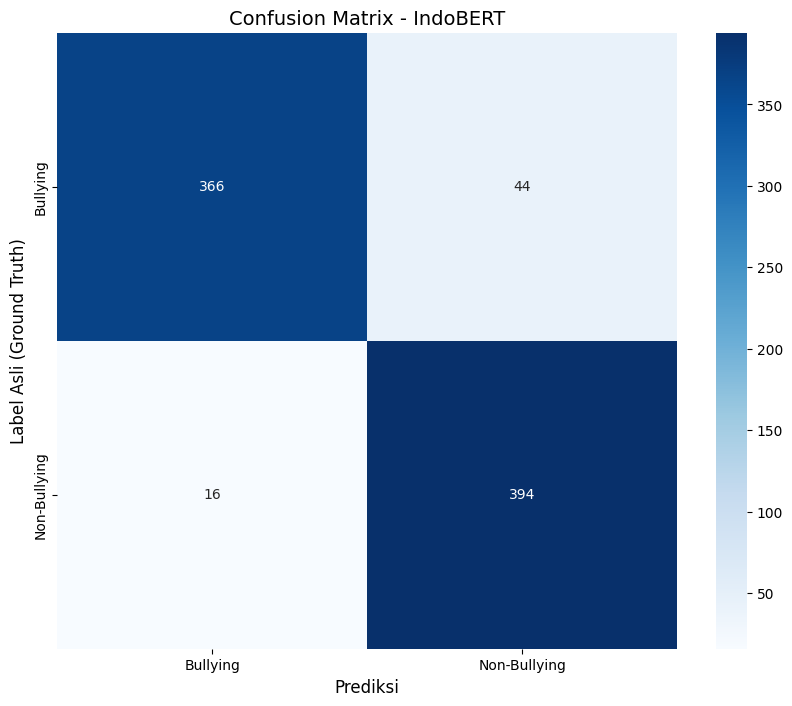

Grafik Confusion Matrix telah disimpan sebagai 'confusion_matrix.png'


In [ ]:
# prediksi dari data test
predictions = trainer_indo.predict(ds_test_indo)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

# Cetak Laporan Klasifikasi
target_names = ["Bullying", "Non-Bullying"]
print("\nCLASSIFICATION REPORT INDOBERT:")
print(classification_report(y_true, y_pred, target_names=target_names))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)

plt.title("Confusion Matrix - IndoBERT", fontsize=14)
plt.xlabel("Prediksi", fontsize=12)
plt.ylabel("Label Asli (Ground Truth)", fontsize=12)

# Simpan gambar
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

print("Grafik Confusion Matrix telah disimpan sebagai 'confusion_matrix.png'")

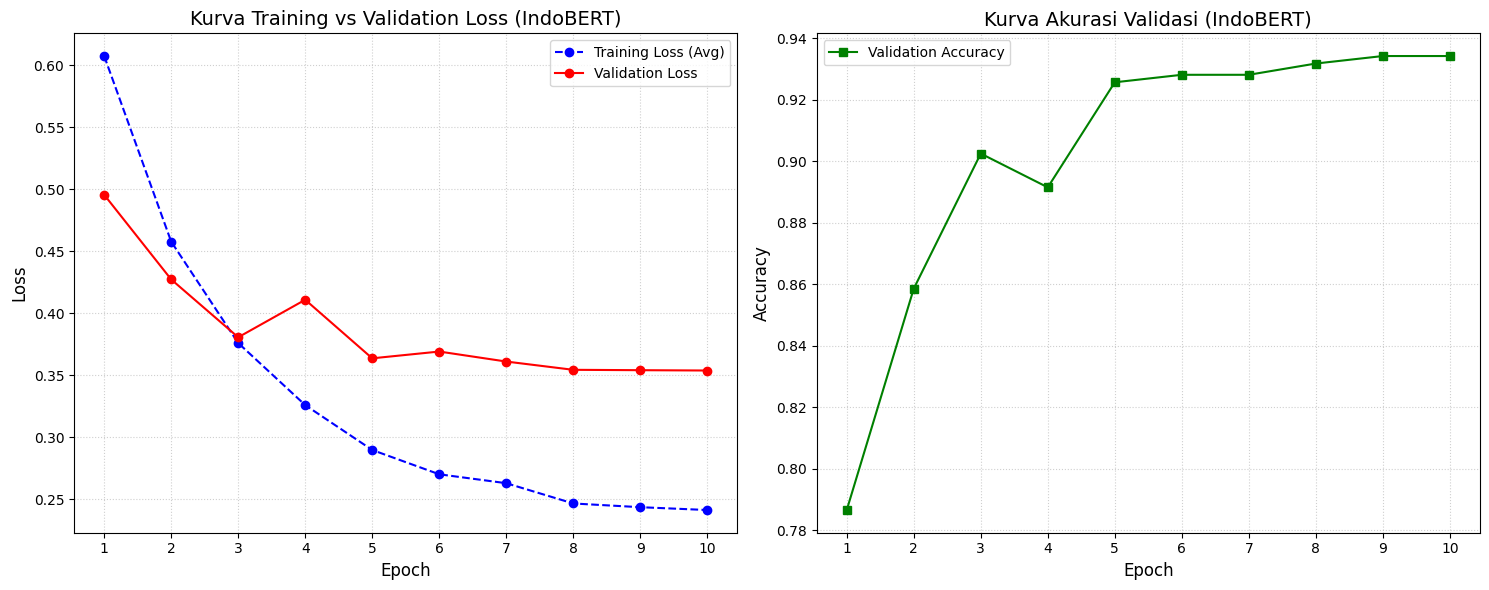

Grafik berhasil disimpan sebagai: visualisasi_performa_indobert_cyberbullying.png


In [ ]:
# Visualisasi Performa IndoBERT
import matplotlib.pyplot as plt
import numpy as np

# Ekstraksi data dari history log trainer IndoBERT
history = trainer_indo.state.log_history

train_loss_all = []
eval_loss = []
eval_accuracy = []
eval_epochs = []

# Memisahkan data berdasarkan ketersediaan kunci dalam log
for log in history:
    if "loss" in log:
        train_loss_all.append(log["loss"])
    if "eval_loss" in log:
        eval_loss.append(log["eval_loss"])
        eval_epochs.append(log["epoch"])
        if "eval_accuracy" in log:
            eval_accuracy.append(log["eval_accuracy"])

# Menyelaraskan dimensi Training Loss dengan jumlah Epoch
if len(eval_epochs) > 0:
    chunks = np.array_split(train_loss_all, len(eval_epochs))
    train_loss_per_epoch = [np.mean(chunk) for chunk in chunks]
else:
    train_loss_per_epoch = []

# Membuat Visualisasi dalam Dua Subplot
plt.figure(figsize=(15, 6))

# Grafik 1: Training vs Validation Loss
plt.subplot(1, 2, 1)
plt.plot(eval_epochs, train_loss_per_epoch, label='Training Loss (Avg)', color='blue', marker='o', linestyle='--')
plt.plot(eval_epochs, eval_loss, label='Validation Loss', color='red', marker='o')
plt.title('Kurva Training vs Validation Loss (IndoBERT)', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(eval_epochs)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Grafik 2: Akurasi Validasi
plt.subplot(1, 2, 2)
plt.plot(eval_epochs, eval_accuracy, label='Validation Accuracy', color='green', marker='s')
plt.title('Kurva Akurasi Validasi (IndoBERT)', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(eval_epochs)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()

# Simpan
nama_file = "visualisasi_performa_indobert_cyberbullying.png"
plt.savefig(nama_file, dpi=300)
plt.show()

print(f"Grafik berhasil disimpan sebagai: {nama_file}")


[INFO] Menghitung probabilitas untuk grafik ROC pada Data Test...


[SUKSES] Data ROC disimpan sebagai: y_score_zsc_indobert.npy


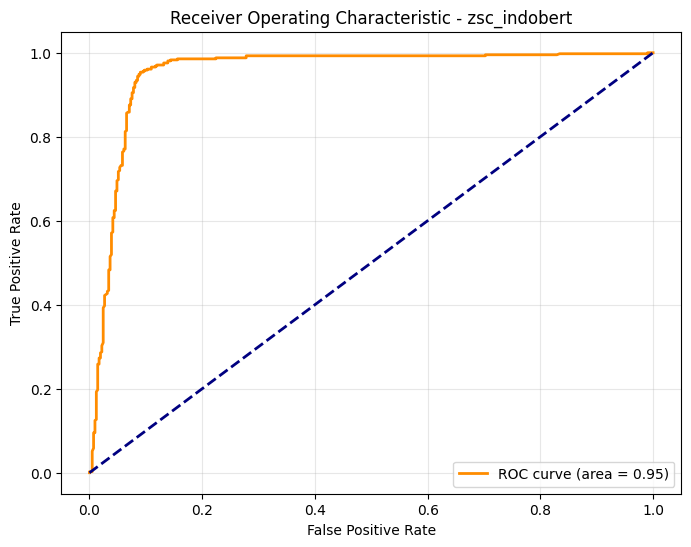

In [ ]:
# ========================================================
# KODE TAMBAHAN UNTUK EKSTRAK DATA ROC (Jalankan setelah train)
# ========================================================
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_curve, auc

print("\n[INFO] Menghitung probabilitas untuk grafik ROC pada Data Test...")

# 1. Jalankan prediksi pada dataset TEST (Bukan Validation)
test_results = trainer_indo.predict(ds_test_indo)

# 2. Ambil Logits
logits = test_results.predictions

# 3. Ubah Logits ke Probabilitas (Softmax)
# Kita ambil kolom [:, 1] karena itu adalah probabilitas kelas 'Bullying'
probs = F.softmax(torch.from_numpy(logits), dim=-1).numpy()
y_score = probs[:, 1]
y_true = test_results.label_ids

# 4. SIMPAN DATA KE FILE .NPY (Agar bisa digabung dengan skenario lain nanti)
# PENTING: Ganti nama file ini sesuai skenario (misal: 'zsc_indobert', 'inset_roberta', dll)
skenario = "zsc_indobert"

np.save(f'y_score_{skenario}.npy', y_score)
np.save(f'y_true_{skenario}.npy', y_true)

print(f"[SUKSES] Data ROC disimpan sebagai: y_score_{skenario}.npy")

# 5. Visualisasi ROC Sederhana (Untuk pengecekan cepat di file ini)
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver Operating Characteristic - {skenario}')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig(f'roc_curve_{skenario}.png', dpi=300)
plt.show()

### RoBERTa

In [ ]:
from transformers import AutoTokenizer, AutoConfig, EarlyStoppingCallback, AutoModelForSequenceClassification, TrainingArguments, Trainer
import torch
import pandas as pd
import numpy as np
import evaluate
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Inisialisasi Tokenizer RoBERTa
model_name_rob = "w11wo/indonesian-roberta-base-sentiment-classifier"
tokenizer_rob = AutoTokenizer.from_pretrained(model_name_rob)

# 2. Tokensiasi Data
train_enc_rob = tokenizer_rob(X_train, truncation=True, padding=True, max_length=128)
val_enc_rob = tokenizer_rob(X_val, truncation=True, padding=True, max_length=128)
test_enc_rob = tokenizer_rob(X_test, truncation=True, padding=True, max_length=128)

# 3. Inisialisasi Dataset
ds_train_rob = SentimentDataset(train_enc_rob, y_train)
ds_val_rob = SentimentDataset(val_enc_rob, y_val)
ds_test_rob = SentimentDataset(test_enc_rob, y_test)




config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [ ]:
# 4. Konfigurasi Model
config_rob = AutoConfig.from_pretrained(
    model_name_rob,
    num_labels=2,
    hidden_dropout_prob=0.3,
    attention_probs_dropout_prob=0.3,
    id2label={0: "non-bullying", 1: "bullying"},
    label2id={"non-bullying": 0, "bullying": 1}
)

model_rob = AutoModelForSequenceClassification.from_pretrained(
    model_name_rob,
    config=config_rob,
    ignore_mismatched_sizes=True
)

# 5. Konfigurasi Fine Tuning
training_args_rob = TrainingArguments(
    output_dir="./res_roberta",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.05,
    label_smoothing_factor=0.1,
    warmup_ratio=0.1,
    fp16=True if torch.cuda.is_available() else False,
    lr_scheduler_type="cosine",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    logging_dir="./logs_roberta",
    logging_steps=50,
    report_to="none"
)

# 6. Inisialisasi Trainer
trainer_rob = Trainer(
    model=model_rob,
    args=training_args_rob,
    train_dataset=ds_train_rob,
    eval_dataset=ds_val_rob,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("=== MEMULAI TRAINING ROBERTA DENGAN REGULASI TINGGI ===")
trainer_rob.train()

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `3`.


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                        | Status   |                                                                                       
---------------------------+----------+---------------------------------------------------------------------------------------
classifier.out_proj.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])
classifier.out_proj.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3]) vs model:torch.Size([2])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


=== MEMULAI TRAINING ROBERTA DENGAN REGULASI TINGGI ===


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3280, training_loss=0.503136284758405, metrics={'train_runtime': 477.1623, 'train_samples_per_second': 137.396, 'train_steps_per_second': 8.592, 'total_flos': 1185907304271360.0, 'train_loss': 0.503136284758405, 'epoch': 8.0})

### Evaluasi RoBERTa


CLASSIFICATION REPORT ROBERTA:
              precision    recall  f1-score   support

Non-Bullying       0.85      0.82      0.83       410
    Bullying       0.82      0.86      0.84       410

    accuracy                           0.84       820
   macro avg       0.84      0.84      0.84       820
weighted avg       0.84      0.84      0.84       820



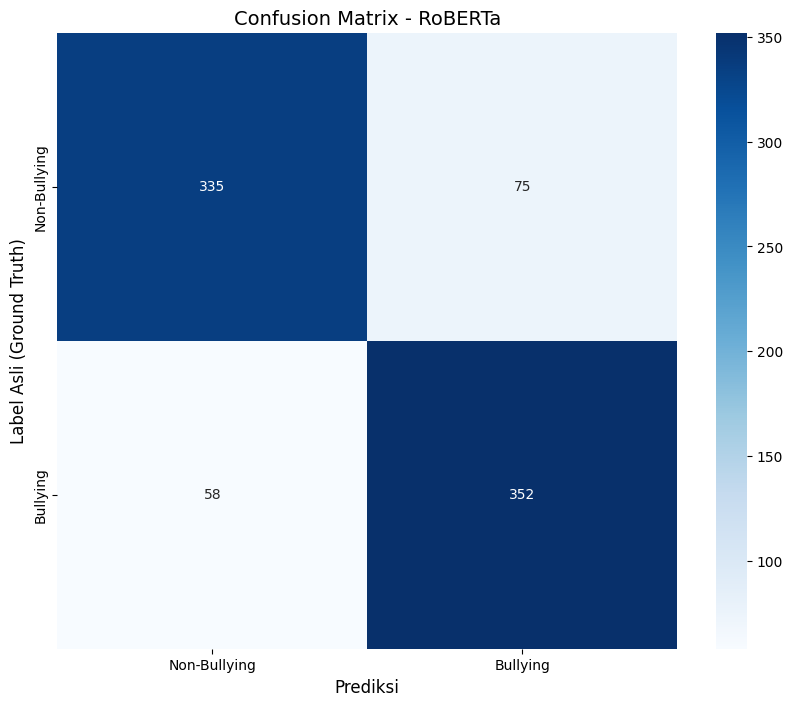

Grafik Confusion Matrix RoBERTa telah disimpan sebagai 'confusion_matrix_roberta.png'


In [ ]:
# 7. Prediksi dan Visualisasi
predictions_rob = trainer_rob.predict(ds_test_rob)
y_pred_rob = np.argmax(predictions_rob.predictions, axis=1)
y_true_rob = predictions_rob.label_ids

# Cetak Laporan Klasifikasi
target_names = ["Non-Bullying", "Bullying"]
print("\nCLASSIFICATION REPORT ROBERTA:")
print(classification_report(y_true_rob, y_pred_rob, target_names=target_names))

# Visualisasi Confusion Matrix
cm_rob = confusion_matrix(y_true_rob, y_pred_rob)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_rob, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)

plt.title("Confusion Matrix - RoBERTa", fontsize=14)
plt.xlabel("Prediksi", fontsize=12)
plt.ylabel("Label Asli (Ground Truth)", fontsize=12)

# Simpan gambar
plt.savefig('confusion_matrix_roberta.png', dpi=300)
plt.show()

print("Grafik Confusion Matrix RoBERTa telah disimpan sebagai 'confusion_matrix_roberta.png'")

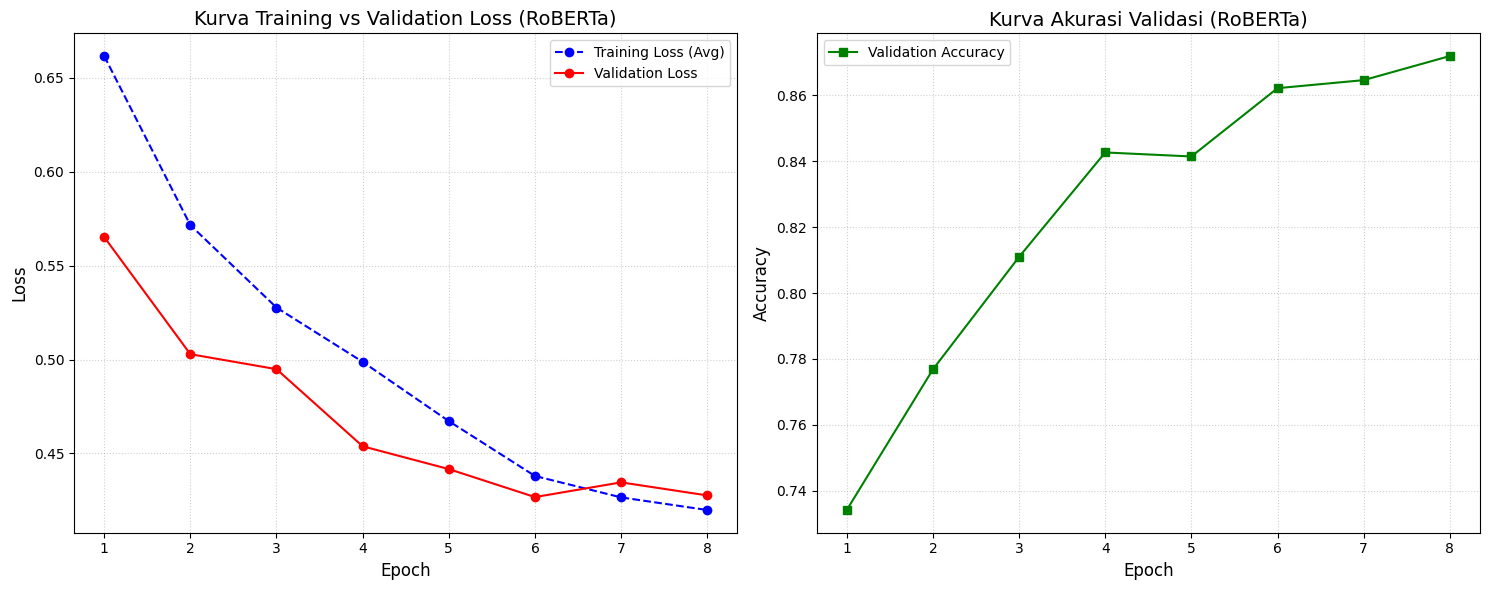

Grafik berhasil disimpan sebagai: visualisasi_performa_roberta_cyberbullying.png


In [ ]:
# Visualisasi Performa RoBERTa
import matplotlib.pyplot as plt
import numpy as np

# Ekstraksi data dari history log trainer RoBERTa
history_rob = trainer_rob.state.log_history

train_loss_all_rob = []
eval_loss_rob = []
eval_accuracy_rob = []
eval_epochs_rob = []

# Memisahkan data berdasarkan ketersediaan kunci dalam log
for log in history_rob:
    if "loss" in log:
        train_loss_all_rob.append(log["loss"])
    if "eval_loss" in log:
        eval_loss_rob.append(log["eval_loss"])
        eval_epochs_rob.append(log["epoch"])
        if "eval_accuracy" in log:
            eval_accuracy_rob.append(log["eval_accuracy"])

# Menyelaraskan dimensi Training Loss dengan jumlah Epoch
if len(eval_epochs_rob) > 0:
    chunks_rob = np.array_split(train_loss_all_rob, len(eval_epochs_rob))
    train_loss_per_epoch_rob = [np.mean(chunk) for chunk in chunks_rob]
else:
    train_loss_per_epoch_rob = []

# Membuat Visualisasi dalam Dua Subplot
plt.figure(figsize=(15, 6))

# Grafik 1: Training vs Validation Loss
plt.subplot(1, 2, 1)
plt.plot(eval_epochs_rob, train_loss_per_epoch_rob, label='Training Loss (Avg)', color='blue', marker='o', linestyle='--')
plt.plot(eval_epochs_rob, eval_loss_rob, label='Validation Loss', color='red', marker='o')
plt.title('Kurva Training vs Validation Loss (RoBERTa)', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(eval_epochs_rob)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Grafik 2: Akurasi Validasi
plt.subplot(1, 2, 2)
plt.plot(eval_epochs_rob, eval_accuracy_rob, label='Validation Accuracy', color='green', marker='s')
plt.title('Kurva Akurasi Validasi (RoBERTa)', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(eval_epochs_rob)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()

# Simpan
nama_file_rob = "visualisasi_performa_roberta_cyberbullying.png"
plt.savefig(nama_file_rob, dpi=300)
plt.show()

print(f"Grafik berhasil disimpan sebagai: {nama_file_rob}")


[INFO] Menghitung probabilitas ROC RoBERTa pada Data Test...


[SUKSES] Data ROC RoBERTa disimpan sebagai: y_score_zsc_roberta.npy


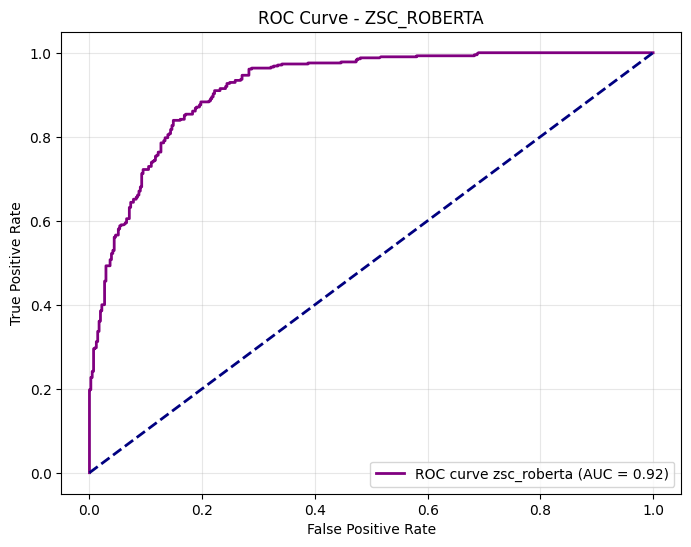

In [ ]:
# ========================================================
# KODE TAMBAHAN UNTUK EKSTRAK DATA ROC ROBERTA
# ========================================================
import torch.nn.functional as F
from sklearn.metrics import roc_curve, auc

print("\n[INFO] Menghitung probabilitas ROC RoBERTa pada Data Test...")

# 1. Jalankan prediksi pada dataset TEST
# Gunakan ds_test_rob agar hasil pengujiannya murni (data yang belum pernah dilihat)
test_results_rob = trainer_rob.predict(ds_test_rob)

# 2. Ambil Logits
logits_rob = test_results_rob.predictions

# 3. Ubah Logits ke Probabilitas (Softmax)
# Kita ambil kolom [:, 1] untuk probabilitas kelas 'Bullying'
probs_rob = F.softmax(torch.from_numpy(logits_rob), dim=-1).numpy()
y_score_rob = probs_rob[:, 1]
y_true_rob = test_results_rob.label_ids

# 4. SIMPAN DATA KE FILE .NPY
# PENTING: Ganti isi variabel 'skenario' ini sesuai file yang sedang kamu run!
# Jika ini file ZSC, tulis "zsc_roberta". Jika ini file InSet, tulis "inset_roberta"
skenario_rob = "zsc_roberta"

np.save(f'y_score_{skenario_rob}.npy', y_score_rob)
np.save(f'y_true_{skenario_rob}.npy', y_true_rob)

print(f"[SUKSES] Data ROC RoBERTa disimpan sebagai: y_score_{skenario_rob}.npy")

# 5. Visualisasi ROC Sederhana (Cek Cepat)
fpr_rob, tpr_rob, _ = roc_curve(y_true_rob, y_score_rob)
roc_auc_rob = auc(fpr_rob, tpr_rob)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rob, tpr_rob, color='purple', lw=2, label=f'ROC curve {skenario_rob} (AUC = {roc_auc_rob:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - {skenario_rob.upper()}')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig(f'roc_curve_{skenario_rob}.png', dpi=300)
plt.show()

## Testing Model

In [ ]:
import torch
import torch.nn.functional as F
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
model.eval()

model_rob.to(device)
model_rob.eval()

# Fungsi prediksi
def predict_cyberbullying(text, model_dipakai, tokenizer_dipakai):
    # 1. Preprocessing sederhana (huruf kecil)
    text_clean = text.lower()
    # 2. Tokenisasi
    inputs = tokenizer_dipakai(text_clean, return_tensors="pt", truncation=True, padding=True, max_length=128).to(device)
    # 3. Mode prediksi
    with torch.no_grad():
        outputs = model_dipakai(**inputs)
    # 4. Hitung persentase keyakinan dengan Softmax
    probs = F.softmax(outputs.logits, dim=-1)
    label_idx = torch.argmax(probs).item()
    # 5. Mapping Label
    target_names = ["Non-Bullying", "Bullying"]

    return target_names[label_idx], probs[0][label_idx].item()


# Contoh
teks_test = "dasar bocah alay gajelas, mending hapus akun aja lu"

print(f"Komentar yang diuji: '{teks_test}'\n")

# 1. Uji menggunakan IndoBERT
hasil_indo, skor_indo = predict_cyberbullying(teks_test, model, tokenizer)
print(f"Prediksi IndoBERT : {hasil_indo} (Tingkat Keyakinan: {skor_indo*100:.2f}%)")

# 2. Uji menggunakan RoBERTa
hasil_rob, skor_rob = predict_cyberbullying(teks_test, model_rob, tokenizer_rob)
print(f"Prediksi RoBERTa  : {hasil_rob} (Tingkat Keyakinan: {skor_rob*100:.2f}%)")

Komentar yang diuji: 'dasar bocah alay gajelas, mending hapus akun aja lu'

Prediksi IndoBERT : Bullying (Tingkat Keyakinan: 95.92%)
Prediksi RoBERTa  : Bullying (Tingkat Keyakinan: 75.21%)


## Komparasi & Save Best Model


=== RINGKASAN HASIL EVALUASI FINAL ===


,Model,Accuracy,F1-Score
0,IndoBERT,0.9268,0.9267
1,RoBERTa,0.8378,0.8377


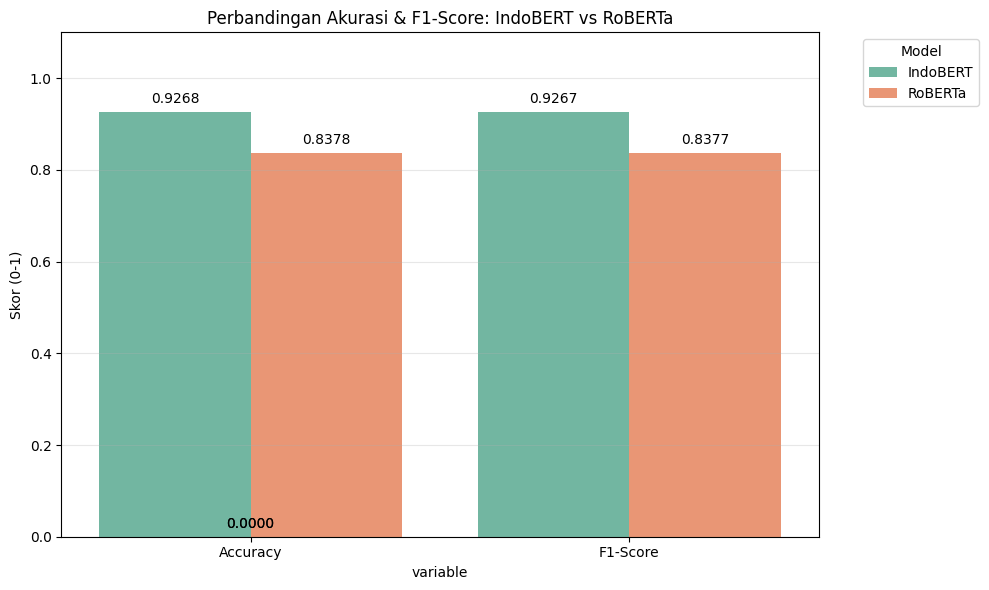


Model Terbaik berdasarkan F1-Score adalah: IndoBERT

Menyimpan model IndoBERT langsung ke Google Drive...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

--- BERHASIL ---
Model terbaik telah disimpan di: /content/drive/MyDrive/KTI/NEW_Best_Model_IndoBERT_ZeroShot


In [ ]:
# Komparasi & Save Best Model (JALAN NINJA - BYPASS EVALUATE BUG)

pred_indo = trainer_indo.predict(ds_test_indo)
pred_rob = trainer_rob.predict(ds_test_rob)

y_true_indo = pred_indo.label_ids
y_pred_indo = np.argmax(pred_indo.predictions, axis=1)

y_true_rob = pred_rob.label_ids
y_pred_rob = np.argmax(pred_rob.predictions, axis=1)

indo_acc = accuracy_score(y_true_indo, y_pred_indo)
indo_f1 = f1_score(y_true_indo, y_pred_indo, average='macro')

rob_acc = accuracy_score(y_true_rob, y_pred_rob)
rob_f1 = f1_score(y_true_rob, y_pred_rob, average='macro')

# 3. Rekap Hasil Evaluasi
hasil_eksperimen = [
    {"Model": "IndoBERT", "Accuracy": indo_acc, "F1-Score": indo_f1},
    {"Model": "RoBERTa", "Accuracy": rob_acc, "F1-Score": rob_f1}
]
df_hasil = pd.DataFrame(hasil_eksperimen)

print("\n=== RINGKASAN HASIL EVALUASI FINAL ===")
pd.options.display.float_format = '{:.4f}'.format
display(df_hasil)

# 4. Visualisasi Bar Chart
df_melt = df_hasil.melt(id_vars=['Model'], value_vars=['Accuracy', 'F1-Score'])
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df_melt,
    x='variable',
    y='value',
    hue='Model',
    palette='Set2'
)

# Menambahkan angka di atas bar
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9), textcoords='offset points')

plt.title('Perbandingan Akurasi & F1-Score: IndoBERT vs RoBERTa')
plt.ylim(0, 1.1)
plt.ylabel('Skor (0-1)')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Penentuan Best Model & Save Model
best_model_name = df_hasil.loc[df_hasil['F1-Score'].idxmax()]['Model']
print(f"\nModel Terbaik berdasarkan F1-Score adalah: {best_model_name}")

# Penyesuaian nama variabel untuk penyimpanan
best_model_to_save = model if best_model_name == "IndoBERT" else model_rob
best_tok_to_save = tokenizer if best_model_name == "IndoBERT" else tokenizer_rob

# Path penyimpanan
SAVE_PATH = f"/content/drive/MyDrive/KTI/NEW_Best_Model_{best_model_name}_ZeroShot"

print(f"\nMenyimpan model {best_model_name} langsung ke Google Drive...")
if not os.path.exists(SAVE_PATH):
    os.makedirs(SAVE_PATH)

best_model_to_save.save_pretrained(SAVE_PATH)
best_tok_to_save.save_pretrained(SAVE_PATH)

print(f"--- BERHASIL ---")
print(f"Model terbaik telah disimpan di: {SAVE_PATH}")